In [46]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [47]:
dataset = pd.read_csv('Salary_dataset.csv')

In [48]:
dataset

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [49]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [50]:
dataset.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [51]:
dataset.shape

(30, 3)

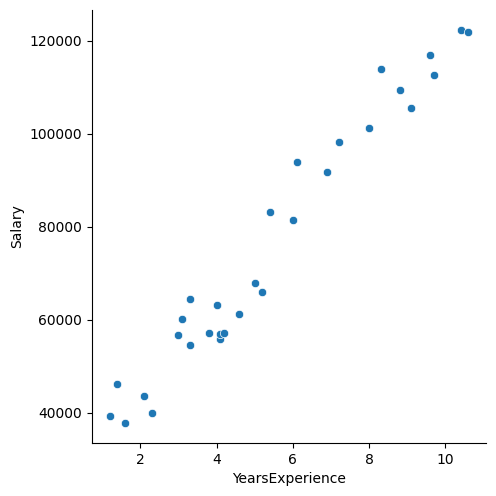

In [52]:
sns.pairplot(dataset,x_vars=['YearsExperience'],y_vars='Salary',size = 5 , kind = 'scatter')

<function matplotlib.pyplot.show(close=None, block=None)>

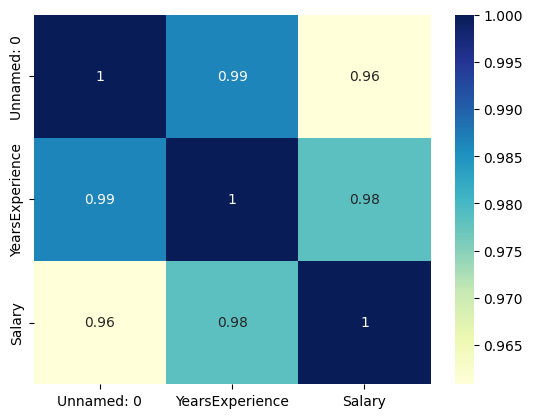

In [53]:
sns.heatmap(dataset.corr(), cmap =  'YlGnBu', annot = True)
plt.show

In [54]:
dataset = dataset.drop('Unnamed: 0', axis=1)

In [55]:
dataset

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


<function matplotlib.pyplot.show(close=None, block=None)>

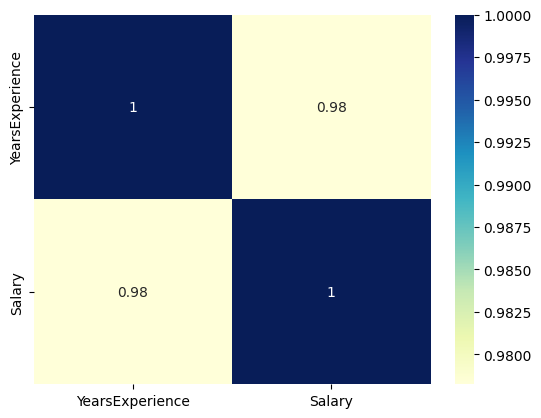

In [56]:
sns.heatmap(dataset.corr(), cmap =  'YlGnBu', annot = True)
plt.show

In [57]:
X = dataset['YearsExperience']
y = dataset['Salary']

In [58]:
# splitting the data into two halves for training 70 and for testing 30.
from sklearn.model_selection import train_test_split
X_train_lm, X_test_lm, y_train_lm, y_test_lm = train_test_split(X,y,train_size=0.7,random_state=6)

In [59]:
X_train_lm

18     6.0
2      1.6
8      3.3
21     7.2
4      2.3
14     4.6
12     4.1
26     9.6
23     8.3
24     8.8
11     4.1
1      1.4
16     5.2
25     9.1
15     5.0
13     4.2
29    10.6
20     6.9
3      2.1
9      3.8
10     4.0
Name: YearsExperience, dtype: float64

In [60]:
X_train_lm.head()

18    6.0
2     1.6
8     3.3
21    7.2
4     2.3
Name: YearsExperience, dtype: float64

In [61]:
X_train_lm = X_train_lm.values.reshape(-1,1)
X_test_lm = X_test_lm.values.reshape(-1,1)

In [62]:
X_train_lm

array([[ 6. ],
       [ 1.6],
       [ 3.3],
       [ 7.2],
       [ 2.3],
       [ 4.6],
       [ 4.1],
       [ 9.6],
       [ 8.3],
       [ 8.8],
       [ 4.1],
       [ 1.4],
       [ 5.2],
       [ 9.1],
       [ 5. ],
       [ 4.2],
       [10.6],
       [ 6.9],
       [ 2.1],
       [ 3.8],
       [ 4. ]])

In [63]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train_lm, y_train_lm)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
LinearRegression()

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
print(lm.intercept_)

22162.881362404085


In [66]:
print(lm.coef_)

[9721.5195311]


In [67]:
y_train_pred = lm.predict(X_train_lm)
y_test_pred = lm.predict(X_test_lm)

In [68]:
from sklearn.metrics import r2_score

In [69]:
print(r2_score(y_train_lm, y_train_pred))

0.9570124270552629


In [71]:
print(r2_score(y_test_lm,y_test_pred))

0.9461285518454471


In [72]:
y_train_pred

array([ 80491.99854901,  37717.31261217,  54243.89581504,  92157.82198633,
        44522.37628394,  66881.87120547,  62021.11143992, 115489.46886097,
       102851.49347054, 107712.25323609,  62021.11143992,  35773.00870595,
        72714.78292413, 110628.70909542,  70770.47901791,  62993.26339303,
       125210.98839207,  89241.366127  ,  42578.07237772,  59104.65558059,
        61048.95948681])

In [73]:
y_test_pred

array([ 33828.70479973, 123266.68448585, 116461.62081408,  52299.59190882,
        74659.08683035,  81464.15050212,  54243.89581504,  51327.43995571,
        99935.03761121])